In [6]:
# 1. LIBRARIES
import os
import csv
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import segmentation_models_pytorch as smp
print(f"PyTorch {torch.__version__} | CUDA AVAILABLE: {torch.cuda.is_available()}")

PyTorch 2.4.1+cu124 | CUDA AVAILABLE: True


In [7]:
# 2. CONFIGURATION
IMG_SIZE = 320
BATCH_SIZE = 8
PHASE1_EPOCHS = 5
PHASE2_EPOCHS = 25
NUM_EPOCHS = PHASE1_EPOCHS + PHASE2_EPOCHS
LR = 1e-4
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [8]:
# 3. PATHS
TRAIN_IMG_DIR = "/workspace/datasets/ISIC2018/images/ISIC2018_Task1-2_Training_Input"
TRAIN_MASK_DIR = "/workspace/datasets/ISIC2018/masks/ISIC2018_Task1_Training_GroundTruth"
TEST_IMG_DIR = "/workspace/datasets/ISIC2018/images/ISIC2018_Task1-2_Test_Input"
TEST_MASK_DIR = "/workspace/datasets/ISIC2018/masks/ISIC2018_Task1_Test_GroundTruth"

train_img_files = sorted([f for f in os.listdir(TRAIN_IMG_DIR)
                           if f.endswith(".jpg") and not f.startswith("._")])
test_img_files = sorted([f for f in os.listdir(TEST_IMG_DIR)
                           if f.endswith(".jpg") and not f.startswith("._")])

print(f"Training images : {len(train_img_files)}")
print(f"Test images     : {len(test_img_files)}")

Training images : 2594
Test images     : 1000


In [9]:
# 4. DATASET
class ISICSegmentationDataset(Dataset):
    def __init__(self, files, img_dir, mask_dir, img_size=320, augment=False):
        self.files    = files
        self.img_dir  = img_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.augment  = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img   = Image.open(os.path.join(self.img_dir, fname)).convert("RGB")
        mask  = Image.open(os.path.join(self.mask_dir,
                           fname.replace(".jpg", "_segmentation.png"))).convert("L")
        img  = TF.resize(img,  (self.img_size, self.img_size), antialias=True)
        mask = TF.resize(mask, (self.img_size, self.img_size), antialias=True)
        if self.augment:
            if random.random() < 0.5:
                img, mask = TF.hflip(img), TF.hflip(mask)
            if random.random() < 0.5:
                img, mask = TF.vflip(img), TF.vflip(mask)
            angle = random.uniform(-30, 30)
            img   = TF.rotate(img,  angle)
            mask  = TF.rotate(mask, angle)
            if random.random() < 0.5:
                scale    = random.uniform(1.0, 1.2)
                new_size = int(self.img_size * scale)
                img  = TF.resize(img,  (new_size, new_size), antialias=True)
                mask = TF.resize(mask, (new_size, new_size), antialias=True)
                img  = TF.center_crop(img,  self.img_size)
                mask = TF.center_crop(mask, self.img_size)
            if random.random() < 0.5:
                img = TF.adjust_brightness(img, random.uniform(0.7, 1.3))
                img = TF.adjust_contrast(img,   random.uniform(0.7, 1.3))
                img = TF.adjust_saturation(img, random.uniform(0.7, 1.3))
                img = TF.adjust_hue(img,        random.uniform(-0.1, 0.1))
            if random.random() < 0.3:
                img = TF.gaussian_blur(img, kernel_size=3)
        img  = TF.to_tensor(img)
        img  = TF.normalize(img, mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])
        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()
        return img, mask, fname


In [10]:
# 5. SPLIT TRAIN / VAL  +  TEST OFICIAL
train_files, val_files = train_test_split(
    train_img_files, test_size=0.15, random_state=SEED
)
test_files = test_img_files  

print(f"Train : {len(train_files)} images")
print(f"Val   : {len(val_files)}   images")
print(f"Test  : {len(test_files)}  images  <- official ISIC 2018 test set")

train_ds = ISICSegmentationDataset(train_files, TRAIN_IMG_DIR, TRAIN_MASK_DIR, IMG_SIZE, augment=True)
val_ds   = ISICSegmentationDataset(val_files,   TRAIN_IMG_DIR, TRAIN_MASK_DIR, IMG_SIZE, augment=False)
test_ds  = ISICSegmentationDataset(test_files,  TEST_IMG_DIR,  TEST_MASK_DIR,  IMG_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)


Train : 2204 images
Val   : 390   images
Test  : 1000  images  <- official ISIC 2018 test set


In [11]:
# 6. U-NET MODEL
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b5",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}  ({n_params/1e6:.1f}M)")

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

Trainable parameters: 31,910,081  (31.9M)


In [12]:
# 7. LOSS + METRICS
def dice_loss(logits, targets, eps=1e-7):
    probs   = torch.sigmoid(logits).view(logits.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter   = (probs * targets).sum(1)
    return 1 - ((2 * inter + eps) / (probs.sum(1) + targets.sum(1) + eps)).mean()

bce_fn = nn.BCEWithLogitsLoss()
def loss_fn(logits, targets):
    return bce_fn(logits, targets) + dice_loss(logits, targets)

def compute_metrics(masks, preds, eps=1e-7):
    m  = masks.view(masks.size(0), -1)
    p  = preds.view(preds.size(0), -1)
    TP = (p * m).sum(1)
    FP = (p * (1 - m)).sum(1)
    FN = ((1 - p) * m).sum(1)
    TN = ((1 - p) * (1 - m)).sum(1)
    dice      = ((2 * TP + eps) / (2 * TP + FP + FN + eps)).mean().item()
    iou       = ((TP + eps) / (TP + FP + FN + eps)).mean().item()
    precision = ((TP + eps) / (TP + FP + eps)).mean().item()
    recall    = ((TP + eps) / (TP + FN + eps)).mean().item()
    spec      = ((TN + eps) / (TN + FP + eps)).mean().item()
    return {"dice": dice, "iou": iou,
            "precision": precision, "recall": recall, "specificity": spec}


In [13]:
# 8. OPTIMIZATION
for param in model.encoder.parameters():
    param.requires_grad = False
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-5
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=3, factor=0.5
)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))


In [14]:
# 9. TRAINING
history  = {"epoch": [], "train_loss": [], "val_dice": [], "val_iou": [], "lr": []}
best_dice = -1.0

for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == PHASE1_EPOCHS + 1:
        print("\n--- Phase 2: unfreezing encoder ---")
        for param in model.encoder.parameters():
            param.requires_grad = True
        optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", patience=3, factor=0.5
        )
    # Train
    model.train()
    train_loss = 0.0
    for imgs, masks, _ in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(imgs)
            loss   = loss_fn(logits, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    # Validation
    model.eval()
    val_metrics = {"dice": 0., "iou": 0., "precision": 0., "recall": 0., "specificity": 0.}
    with torch.no_grad():
        for imgs, masks, _ in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            probs = torch.sigmoid(model(imgs))
            preds = (probs > 0.5).float()
            batch = compute_metrics(masks, preds)
            for k in val_metrics:
                val_metrics[k] += batch[k]
    for k in val_metrics:
        val_metrics[k] /= len(val_loader)
    scheduler.step(val_metrics["dice"])
    current_lr = optimizer.param_groups[0]["lr"]
    if val_metrics["dice"] > best_dice:
        best_dice = val_metrics["dice"]
        torch.save(model.state_dict(), "unet_best.pth")
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_dice"].append(val_metrics["dice"])
    history["val_iou"].append(val_metrics["iou"])
    history["lr"].append(current_lr)
    print(f"[{epoch:02d}/{NUM_EPOCHS}] "
          f"loss: {train_loss:.4f} | "
          f"val Dice: {val_metrics['dice']:.4f} | "
          f"IoU: {val_metrics['iou']:.4f} | "
          f"Prec: {val_metrics['precision']:.4f} | "
          f"Rec: {val_metrics['recall']:.4f} | "
          f"LR: {current_lr:.2e}")

with open("training_history.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=history.keys())
    writer.writeheader()
    for row in zip(*history.values()):
        writer.writerow(dict(zip(history.keys(), row)))
print(f"\nBest Val Dice: {best_dice:.4f}  →  model saved in unet_best.pth")


[01/30] loss: 0.5412 | val Dice: 0.8362 | IoU: 0.7476 | Prec: 0.8961 | Rec: 0.8322 | LR: 1.00e-03
[02/30] loss: 0.3985 | val Dice: 0.8419 | IoU: 0.7597 | Prec: 0.9211 | Rec: 0.8283 | LR: 1.00e-03
[03/30] loss: 0.3837 | val Dice: 0.8516 | IoU: 0.7658 | Prec: 0.8822 | Rec: 0.8707 | LR: 1.00e-03
[04/30] loss: 0.3524 | val Dice: 0.8491 | IoU: 0.7633 | Prec: 0.9034 | Rec: 0.8471 | LR: 1.00e-03
[05/30] loss: 0.3372 | val Dice: 0.8601 | IoU: 0.7791 | Prec: 0.8904 | Rec: 0.8781 | LR: 1.00e-03

--- Phase 2: unfreezing encoder ---
[06/30] loss: 0.2822 | val Dice: 0.8748 | IoU: 0.7995 | Prec: 0.9359 | Rec: 0.8582 | LR: 1.00e-04
[07/30] loss: 0.2436 | val Dice: 0.8876 | IoU: 0.8165 | Prec: 0.9254 | Rec: 0.8869 | LR: 1.00e-04
[08/30] loss: 0.2297 | val Dice: 0.8905 | IoU: 0.8181 | Prec: 0.9230 | Rec: 0.8905 | LR: 1.00e-04
[09/30] loss: 0.2212 | val Dice: 0.8937 | IoU: 0.8234 | Prec: 0.9199 | Rec: 0.8995 | LR: 1.00e-04
[10/30] loss: 0.2024 | val Dice: 0.8934 | IoU: 0.8231 | Prec: 0.9214 | Rec: 0.897

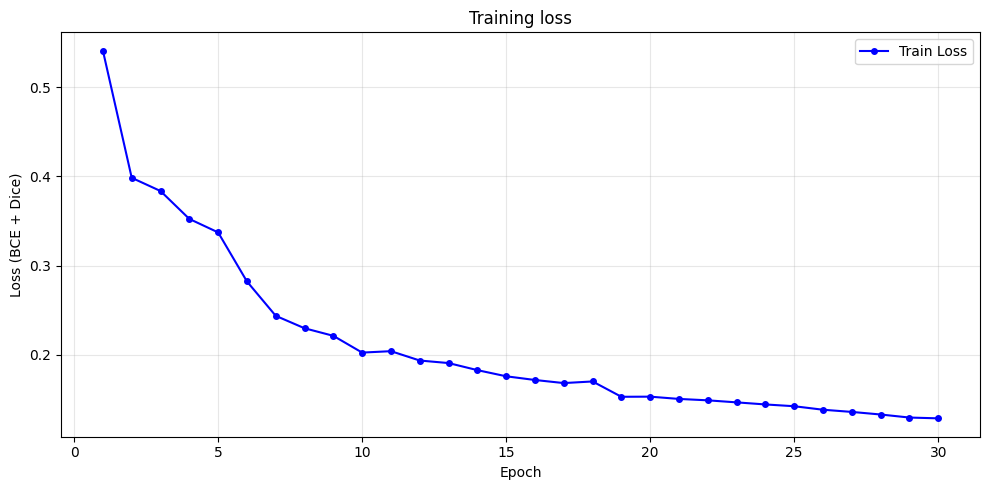

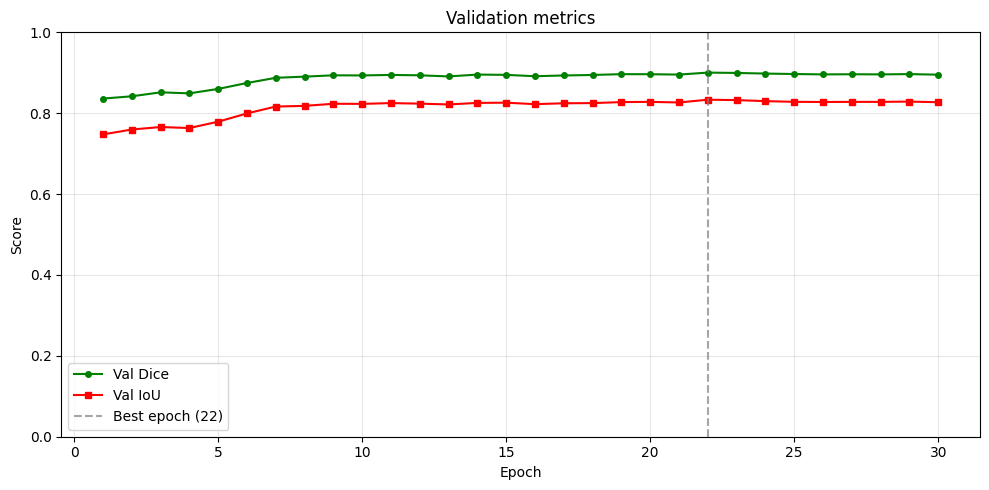

In [15]:
# 10. LEARNING CURVES
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["epoch"], history["train_loss"], "b-o", markersize=4, label="Train Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (BCE + Dice)")
ax.set_title("Training loss"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("learning_curve_loss.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["epoch"], history["val_dice"], "g-o", markersize=4, label="Val Dice")
ax.plot(history["epoch"], history["val_iou"],  "r-s", markersize=4, label="Val IoU")
best_epoch = history["val_dice"].index(max(history["val_dice"])) + 1
ax.axvline(best_epoch, color="gray", linestyle="--", alpha=0.7,
           label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch"); ax.set_ylabel("Score")
ax.set_title("Validation metrics"); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("learning_curve_val.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# 11. FINAL EVALUATION — OFFICIAL TEST SET
model.load_state_dict(torch.load("unet_best.pth", map_location=device, weights_only=True))
model.eval()
test_metrics   = {"dice": 0., "iou": 0., "precision": 0., "recall": 0., "specificity": 0.}
all_dice_scores = []

with torch.no_grad():
    for imgs, masks, _ in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        probs = torch.sigmoid(model(imgs))
        preds = (probs > 0.5).float()
        batch = compute_metrics(masks, preds)
        for k in test_metrics:
            test_metrics[k] += batch[k]
        m = masks.view(masks.size(0), -1)
        p = preds.view(preds.size(0), -1)
        eps = 1e-7
        per_img_dice = ((2 * (p * m).sum(1) + eps) /
                        (p.sum(1) + m.sum(1) + eps)).cpu().numpy()
        all_dice_scores.extend(per_img_dice.tolist())

for k in test_metrics:
    test_metrics[k] /= len(test_loader)
dice_std = np.std(all_dice_scores)
print("=" * 50)
print("  FINAL RESULTS — OFFICIAL TEST SET (ISIC 2018)")
print("=" * 50)
print(f"  Dice / F1      : {test_metrics['dice']:.4f}  (±{dice_std:.4f})")
print(f"  IoU / Jaccard  : {test_metrics['iou']:.4f}")
print(f"  Precision      : {test_metrics['precision']:.4f}")
print(f"  Recall (Sens.) : {test_metrics['recall']:.4f}")
print(f"  Specificity    : {test_metrics['specificity']:.4f}")
print(f"  Total test images: {len(all_dice_scores)}")
print("=" * 50)

with open("test_results.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["metric", "value"])
    for k, v in test_metrics.items():
        writer.writerow([k, f"{v:.6f}"])
    writer.writerow(["dice_std", f"{dice_std:.6f}"])
print("Results saved in test_results.csv")


  FINAL RESULTS — OFFICIAL TEST SET (ISIC 2018)
  Dice / F1      : 0.8845  (±0.1078)
  IoU / Jaccard  : 0.8062
  Precision      : 0.8452
  Recall (Sens.) : 0.9549
  Specificity    : 0.9274
  Total test images: 1000
Results saved in test_results.csv


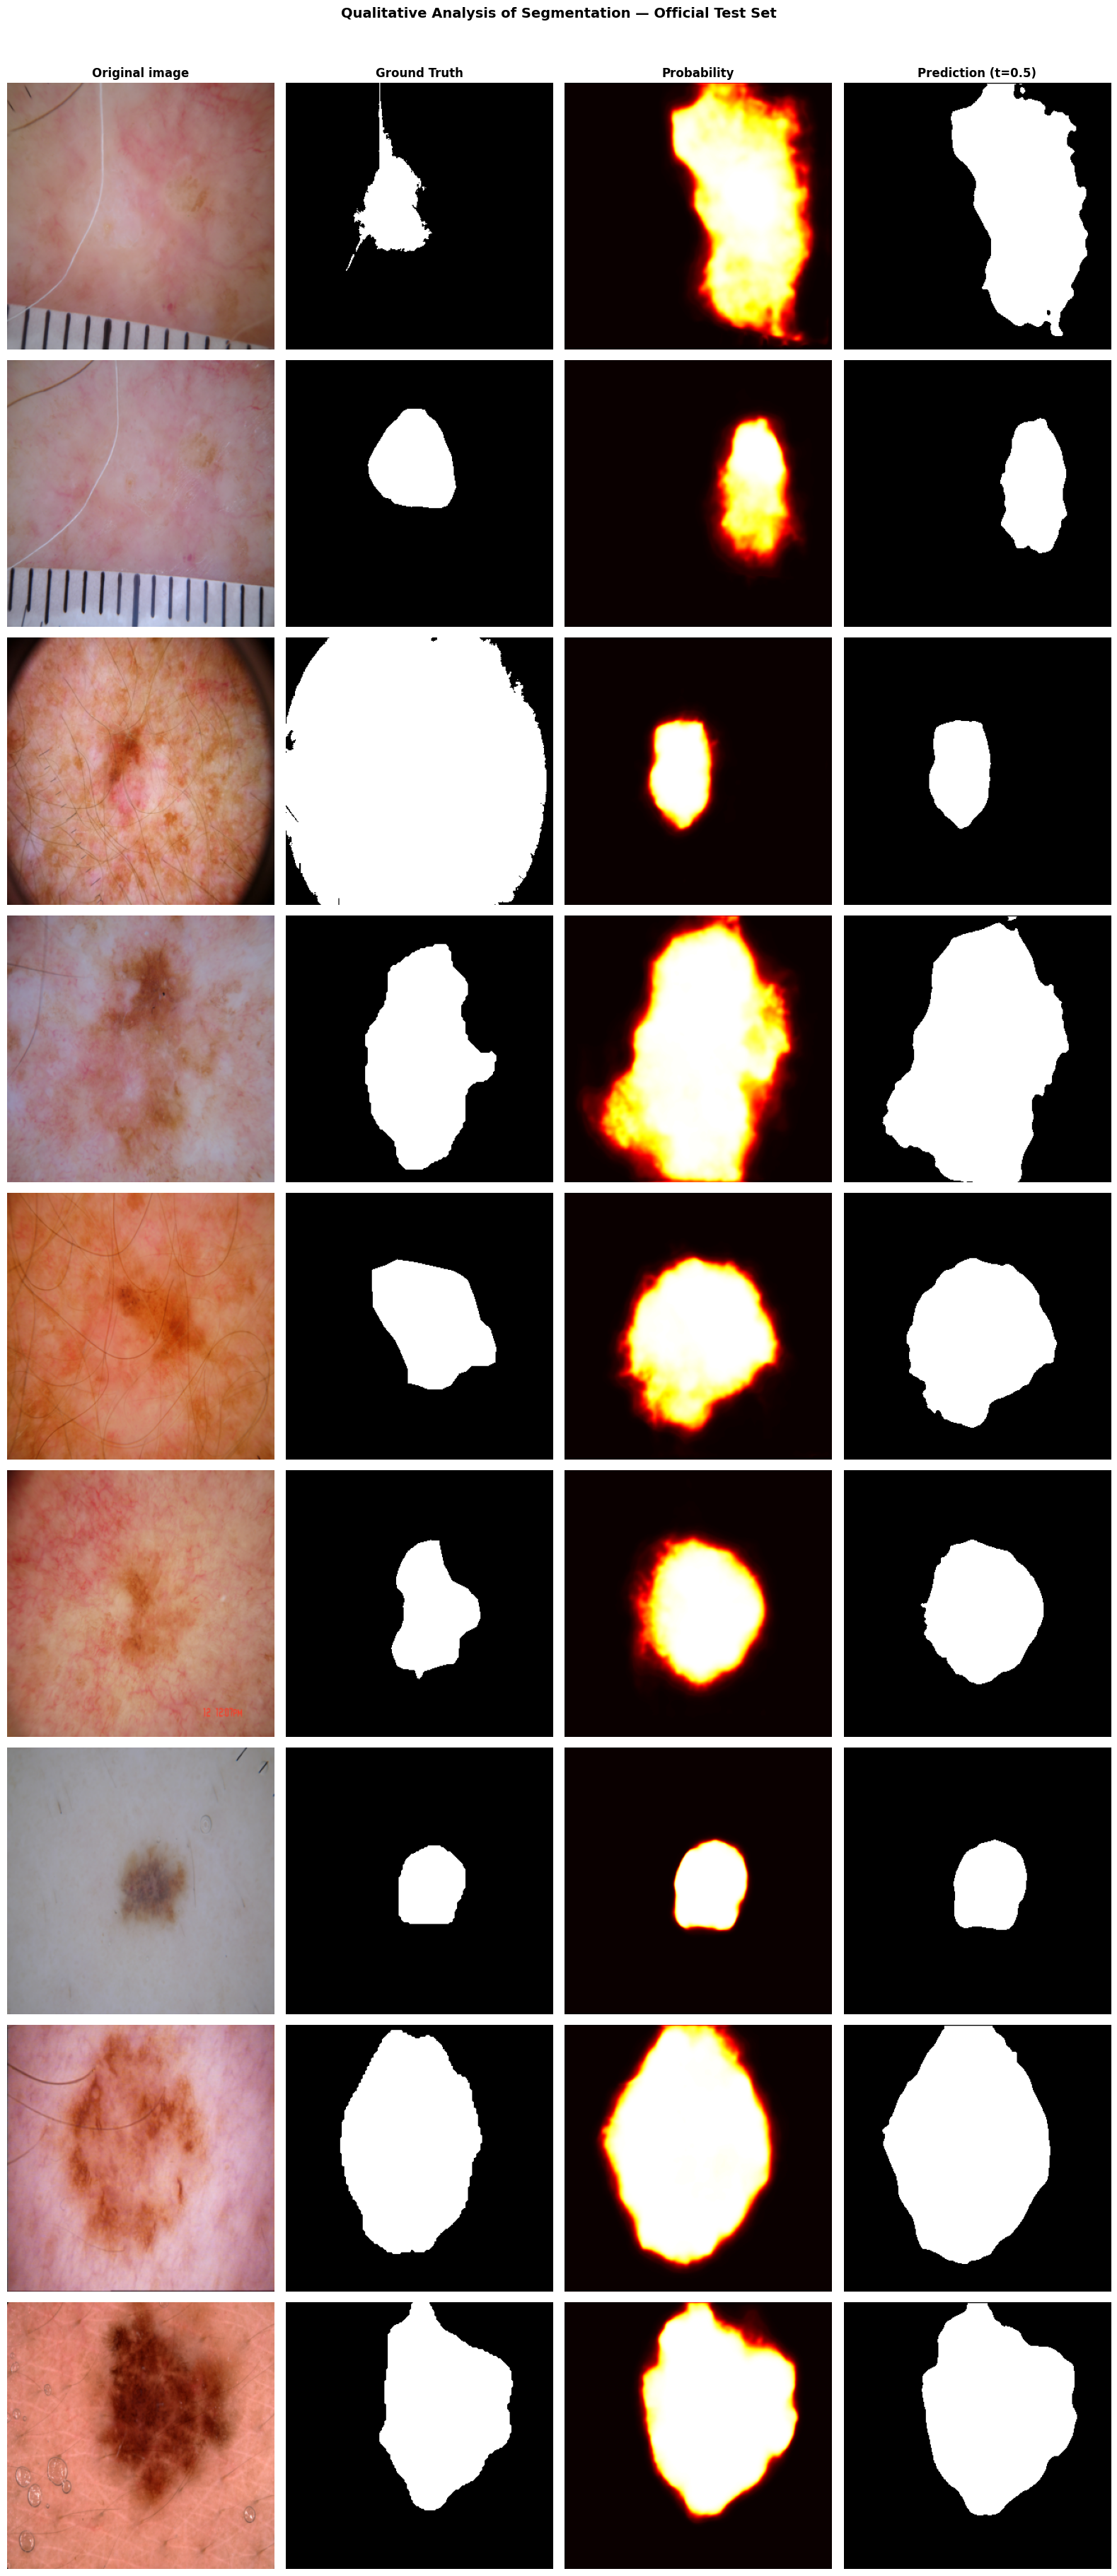

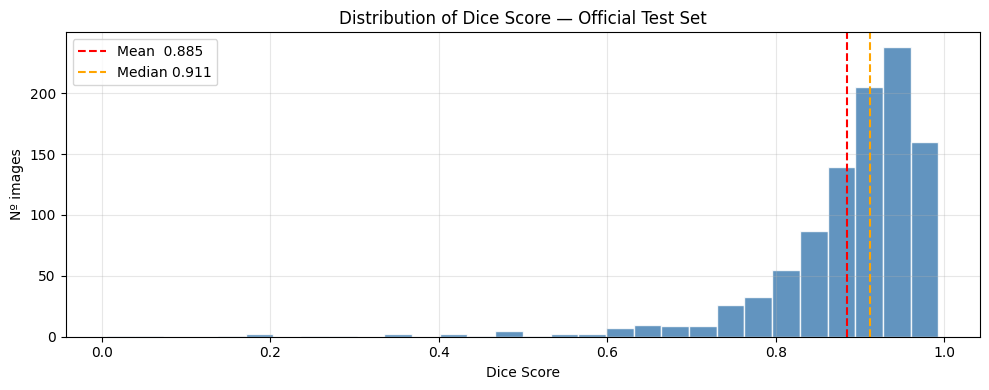

In [17]:
# 12. QUALITATIVE VISUALIZATION
model.eval()
per_image_results = []

with torch.no_grad():
    for imgs, masks, fnames in test_loader:
        imgs_d, masks_d = imgs.to(device), masks.to(device)
        probs_d = torch.sigmoid(model(imgs_d))
        preds_d = (probs_d > 0.5).float()
        m = masks_d.view(masks_d.size(0), -1)
        p = preds_d.view(preds_d.size(0), -1)
        eps = 1e-7
        dice_per = ((2*(p*m).sum(1)+eps) / (p.sum(1)+m.sum(1)+eps)).cpu()
        for i in range(len(fnames)):
            per_image_results.append((
                dice_per[i].item(),
                imgs[i].cpu(),
                masks[i].cpu(),
                probs_d[i].cpu(),
                fnames[i]
            ))

per_image_results.sort(key=lambda x: x[0])
good    = [r for r in per_image_results if r[0] > 0.90]
mid     = [r for r in per_image_results if 0.75 <= r[0] <= 0.90]
hard    = [r for r in per_image_results if r[0] < 0.75]
samples = (hard[:3] + mid[:3] + good[:3])
group_labels = (["Difficult"]*min(3,len(hard)) +
                ["Limit"]*min(3,len(mid)) +
                ["Good"]*min(3,len(good)))
group_colors = {"Difficult": "#d62728", "Limit": "#ff7f0e", "Good": "#2ca02c"}

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
def denorm(t):
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

n = len(samples)
fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
fig.suptitle("Qualitative Analysis of Segmentation — Official Test Set",
             fontsize=14, fontweight="bold", y=1.01)
col_titles = ["Original image", "Ground Truth", "Probability", "Prediction (t=0.5)"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight="bold")
for row, (result, glabel) in enumerate(zip(samples, group_labels)):
    dice_val, img_t, mask_t, prob_t, fname = result
    color   = group_colors[glabel]
    pred_t  = (prob_t > 0.5).float()
    img_np  = denorm(img_t)
    mask_np = mask_t.squeeze().numpy()
    prob_np = prob_t.squeeze().numpy()
    pred_np = pred_t.squeeze().numpy()
    axes[row, 0].imshow(img_np);                    axes[row, 0].axis("off")
    axes[row, 1].imshow(mask_np, cmap="gray");      axes[row, 1].axis("off")
    axes[row, 2].imshow(prob_np, cmap="hot");       axes[row, 2].axis("off")
    axes[row, 3].imshow(pred_np, cmap="gray");      axes[row, 3].axis("off")
    axes[row, 0].set_ylabel(f"{glabel}\nDice={dice_val:.3f}",
                             fontsize=10, color=color, fontweight="bold",
                             rotation=0, labelpad=60, va="center")
    for col in range(4):
        for spine in axes[row, col].spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2)
plt.tight_layout()
plt.savefig("visualizacion_cualitativa.png", dpi=150, bbox_inches="tight")
plt.show()

all_dices = [r[0] for r in per_image_results]
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_dices, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(np.mean(all_dices),   color="red",    linestyle="--",
           label=f"Mean  {np.mean(all_dices):.3f}")
ax.axvline(np.median(all_dices), color="orange", linestyle="--",
           label=f"Median {np.median(all_dices):.3f}")
ax.set_xlabel("Dice Score"); ax.set_ylabel("Nº images")
ax.set_title("Distribution of Dice Score — Official Test Set")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("histograma_dice.png", dpi=150, bbox_inches="tight")
plt.show()


In [18]:
# 13. FINAL SUMMARY
print("=" * 60)
print("  SUMMARY — TFG Dermoscopic Segmentation")
print("=" * 60)
print(f"  Dataset        : ISIC 2018 Task 1")
print(f"  Architecture   : U-Net++ + EfficientNet-B5 encoder")
print(f"  Parameters     : {n_params:,}  ({n_params/1e6:.1f}M)")
print(f"  Resolution     : {IMG_SIZE}×{IMG_SIZE} px")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Epochs         : {NUM_EPOCHS}")
print(f"  Loss           : BCE + Dice Loss")
print(f"  Optimizer      : Adam  (weight_decay=1e-5)")
print(f"  Scheduler      : ReduceLROnPlateau (patience=3, factor=0.5)")
print(f"  Split          : 85/15 train/val + official ISIC 2018 test set")
print()
print("  ── OFFICIAL TEST SET RESULTS ─────────────────────")
print(f"  Dice / F1      : {test_metrics['dice']:.4f}  (±{dice_std:.4f})")
print(f"  IoU / Jaccard  : {test_metrics['iou']:.4f}")
print(f"  Precision      : {test_metrics['precision']:.4f}")
print(f"  Recall         : {test_metrics['recall']:.4f}")
print(f"  Specificity    : {test_metrics['specificity']:.4f}")
print("=" * 60)

  SUMMARY — TFG Dermoscopic Segmentation
  Dataset        : ISIC 2018 Task 1
  Architecture   : U-Net++ + EfficientNet-B5 encoder
  Parameters     : 31,910,081  (31.9M)
  Resolution     : 320×320 px
  Batch size     : 8
  Epochs         : 30
  Loss           : BCE + Dice Loss
  Optimizer      : Adam  (weight_decay=1e-5)
  Scheduler      : ReduceLROnPlateau (patience=3, factor=0.5)
  Split          : 85/15 train/val + official ISIC 2018 test set

  ── OFFICIAL TEST SET RESULTS ─────────────────────
  Dice / F1      : 0.8845  (±0.1078)
  IoU / Jaccard  : 0.8062
  Precision      : 0.8452
  Recall         : 0.9549
  Specificity    : 0.9274


In [19]:
# 14. SAVE ALL RESULTS
import shutil
output_folder = "TFG_Segmentation_Results"
os.makedirs(output_folder, exist_ok=True)
files_to_save = [
    "unet_best.pth",
    "training_history.csv",
    "test_results.csv",
    "learning_curve_loss.png",
    "learning_curve_val.png",
    "visualizacion_cualitativa.png",
    "histograma_dice.png",
]
for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(output_folder, f))
        print(f"✓ {f}")
    else:
        print(f"✗ {f} no encontrado")
shutil.make_archive("TFG_Segmentation_Results", "zip", output_folder)
print("\nZIP created: TFG_Segmentation_Results.zip")

✓ unet_best.pth
✓ training_history.csv
✓ test_results.csv
✓ learning_curve_loss.png
✓ learning_curve_val.png
✓ visualizacion_cualitativa.png
✓ histograma_dice.png

ZIP created: TFG_Segmentation_Results.zip
